In [1]:
import numpy as np
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from matplotlib.colors import LogNorm
from scipy.stats import binned_statistic_2d
import pickle

import data_processing as dp

In [2]:
#Data path and data containers
# file_pattern = "/home/nstrobbe/mahon/hgcalmlSingularity/hgcal_minimal_eval_example/output/singlePhoton24-04-01/FTFP_BERT_EMN/*.pkl"
file_limit = 1000
species = "Tau"
sample = "nominal"
particleEnergy = "e50"

data, pass_noise_filter, out_gravnet = dp.load_data_bulk(sample, particleEnergy, species)
layer_positions = np.loadtxt("unique_z.txt")


In [ ]:
# #no shortcuts lets make this z and r bins to make everything easier
# x_all = np.concatenate(np.array([ data[i].x[:,5] for i in range(file_limit) ], dtype=object))
# y_all = np.concatenate(np.array([ data[i].x[:,6] for i in range(file_limit) ], dtype=object))
# z_all = np.concatenate(np.array([ np.round(data[i].x[:,7]) for i in range(file_limit) ], dtype=object))
# r_all = (x_all**2 + y_all**2)**0.5
# z_all_index = np.asarray([np.argmin(np.abs(layer_positions-np.asarray(x))) for x in z_all ])
# a = plt.hist2d(z_all_index,r_all, bins=(np.arange(0,51),list(range(20,261,2))))
# with open("rzTauBinning.pkl","wb") as file:
#     pickle.dump(a[0], file)

In [14]:
# Data processing - come get your variables
# Masks
true_cluster = np.array([ data[i].y for i in range(file_limit)], dtype=object) # real hits==1
final_pred_hits = np.array([ dp.process_gravnet(pass_noise_filter[i], out_gravnet[i]) for i in range(file_limit)], dtype=object) #real clusterHits>0

# 0 recHitEnergy,
# 1 recHitEta,
# 2 zeroFeature, #indicator if it is track or not
# 3 recHitTheta,
# 4 recHitR,
# 5 recHitX,
# 6 recHitY,
# 7 recHitZ,
# 8 recHitTime

# true data
energy_true = np.array([ data[i].x[:,0][true_cluster[i]==1] for i in range(file_limit) ], dtype=object)
x_true = np.array([ data[i].x[:,5][true_cluster[i]==1] for i in range(file_limit) ], dtype=object)
y_true = np.array([ data[i].x[:,6][true_cluster[i]==1] for i in range(file_limit) ], dtype=object)
z_true = np.array([ np.round(data[i].x[:,7][true_cluster[i]==1]) for i in range(file_limit) ], dtype=object)
t_true = np.array([ data[i].x[:,8][true_cluster[i]==1] for i in range(file_limit) ], dtype=object)
r_true = np.array([ data[i].x[:,4][true_cluster[i]==1] for i in range(file_limit) ], dtype=object)

# predicted data
energy_pred = np.array([ data[i].x[:,0][final_pred_hits[i] > 0] for i in range(file_limit) ], dtype=object)
x_pred= np.array([ data[i].x[:,5][final_pred_hits[i] > 0] for i in range(file_limit) ], dtype=object)
y_pred = np.array([ data[i].x[:,6][final_pred_hits[i] > 0] for i in range(file_limit) ], dtype=object)
z_pred = np.array([ np.round(data[i].x[:,7][final_pred_hits[i] > 0]) for i in range(file_limit) ], dtype=object)
t_pred = np.array([ data[i].x[:,8][final_pred_hits[i] > 0] for i in range(file_limit) ], dtype=object)
r_pred = np.array([ data[i].x[:,4][final_pred_hits[i] > 0] for i in range(file_limit) ], dtype=object)

# del true_cluster, final_pred_hits, data, score_noise_filter, pass_noise_filter, out_gravnet

# Timing studies
t_true_cut = [np.asarray(t_true[i]) != -1 for i in range(1000)]
t_pred_cut = [np.asarray(t_pred[i]) != -1 for i in range(1000)]

z_true_index = np.asarray([np.asarray([np.argmin(np.abs(layer_positions-np.asarray(x))) for x in z_true[i] ]) for i in range(1000)], dtype=object)
z_pred_index = np.asarray([np.asarray([np.argmin(np.abs(layer_positions-np.asarray(x))) for x in z_pred[i] ]) for i in range(1000)], dtype=object)

z_true_flat = np.concatenate(z_true_index)[np.concatenate(t_true_cut)]
z_pred_flat = np.concatenate(z_pred_index)[np.concatenate(t_pred_cut)]

r_true_flat = ((np.concatenate(x_true)**2 + np.concatenate(y_true)**2)**0.5)[np.concatenate(t_true_cut)]
r_pred_flat = ((np.concatenate(x_pred)**2 + np.concatenate(y_pred)**2)**0.5)[np.concatenate(t_pred_cut)]

t_true_flat = np.concatenate(t_true)[np.concatenate(t_true_cut)]
t_pred_flat = np.concatenate(t_pred)[np.concatenate(t_pred_cut)]
t_true_flat_ecal = np.concatenate(t_true)[(np.concatenate(t_true_cut)) & (np.concatenate(z_true_index) < 28)]
t_pred_flat_ecal = np.concatenate(t_pred)[(np.concatenate(t_pred_cut)) & (np.concatenate(z_pred_index) < 28)]
t_true_flat_hcal = np.concatenate(t_true)[(np.concatenate(t_true_cut)) & (np.concatenate(z_true_index) >= 28)]
t_pred_flat_hcal = np.concatenate(t_pred)[(np.concatenate(t_pred_cut)) & (np.concatenate(z_pred_index) >= 28)]

t_true_avg = [ np.mean(np.asarray(t_true[i][t_true_cut[i]])) for i in range(1000)]
t_pred_avg = [ np.mean(np.asarray(t_pred[i][t_pred_cut[i]])) for i in range(1000)]
t_true_avg_ecal = [ np.mean(np.asarray(t_true[i][(t_true_cut[i]) & (z_true_index[i] < 28)])) for i in range(1000)]
t_pred_avg_ecal = [ np.mean(np.asarray(t_pred[i][(t_pred_cut[i]) & (z_pred_index[i] < 28)])) for i in range(1000)]
t_true_avg_hcal = [ np.mean(np.asarray(t_true[i][(t_true_cut[i]) & (z_true_index[i] >= 28)])) for i in range(1000)]
t_pred_avg_hcal = [ np.mean(np.asarray(t_pred[i][(t_pred_cut[i]) & (z_pred_index[i] >= 28)])) for i in range(1000)]

t_true_early = [len(np.asarray(t_true[i][(t_true_cut[i]) & (np.asarray(t_true[i]) < 4.8)])) for i in range(1000)]



/users/6/vadna042/.conda/envs/airobust/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/users/6/vadna042/.conda/envs/airobust/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


Text(0.5, 1.0, 'Heat Map of Average Time Hit')

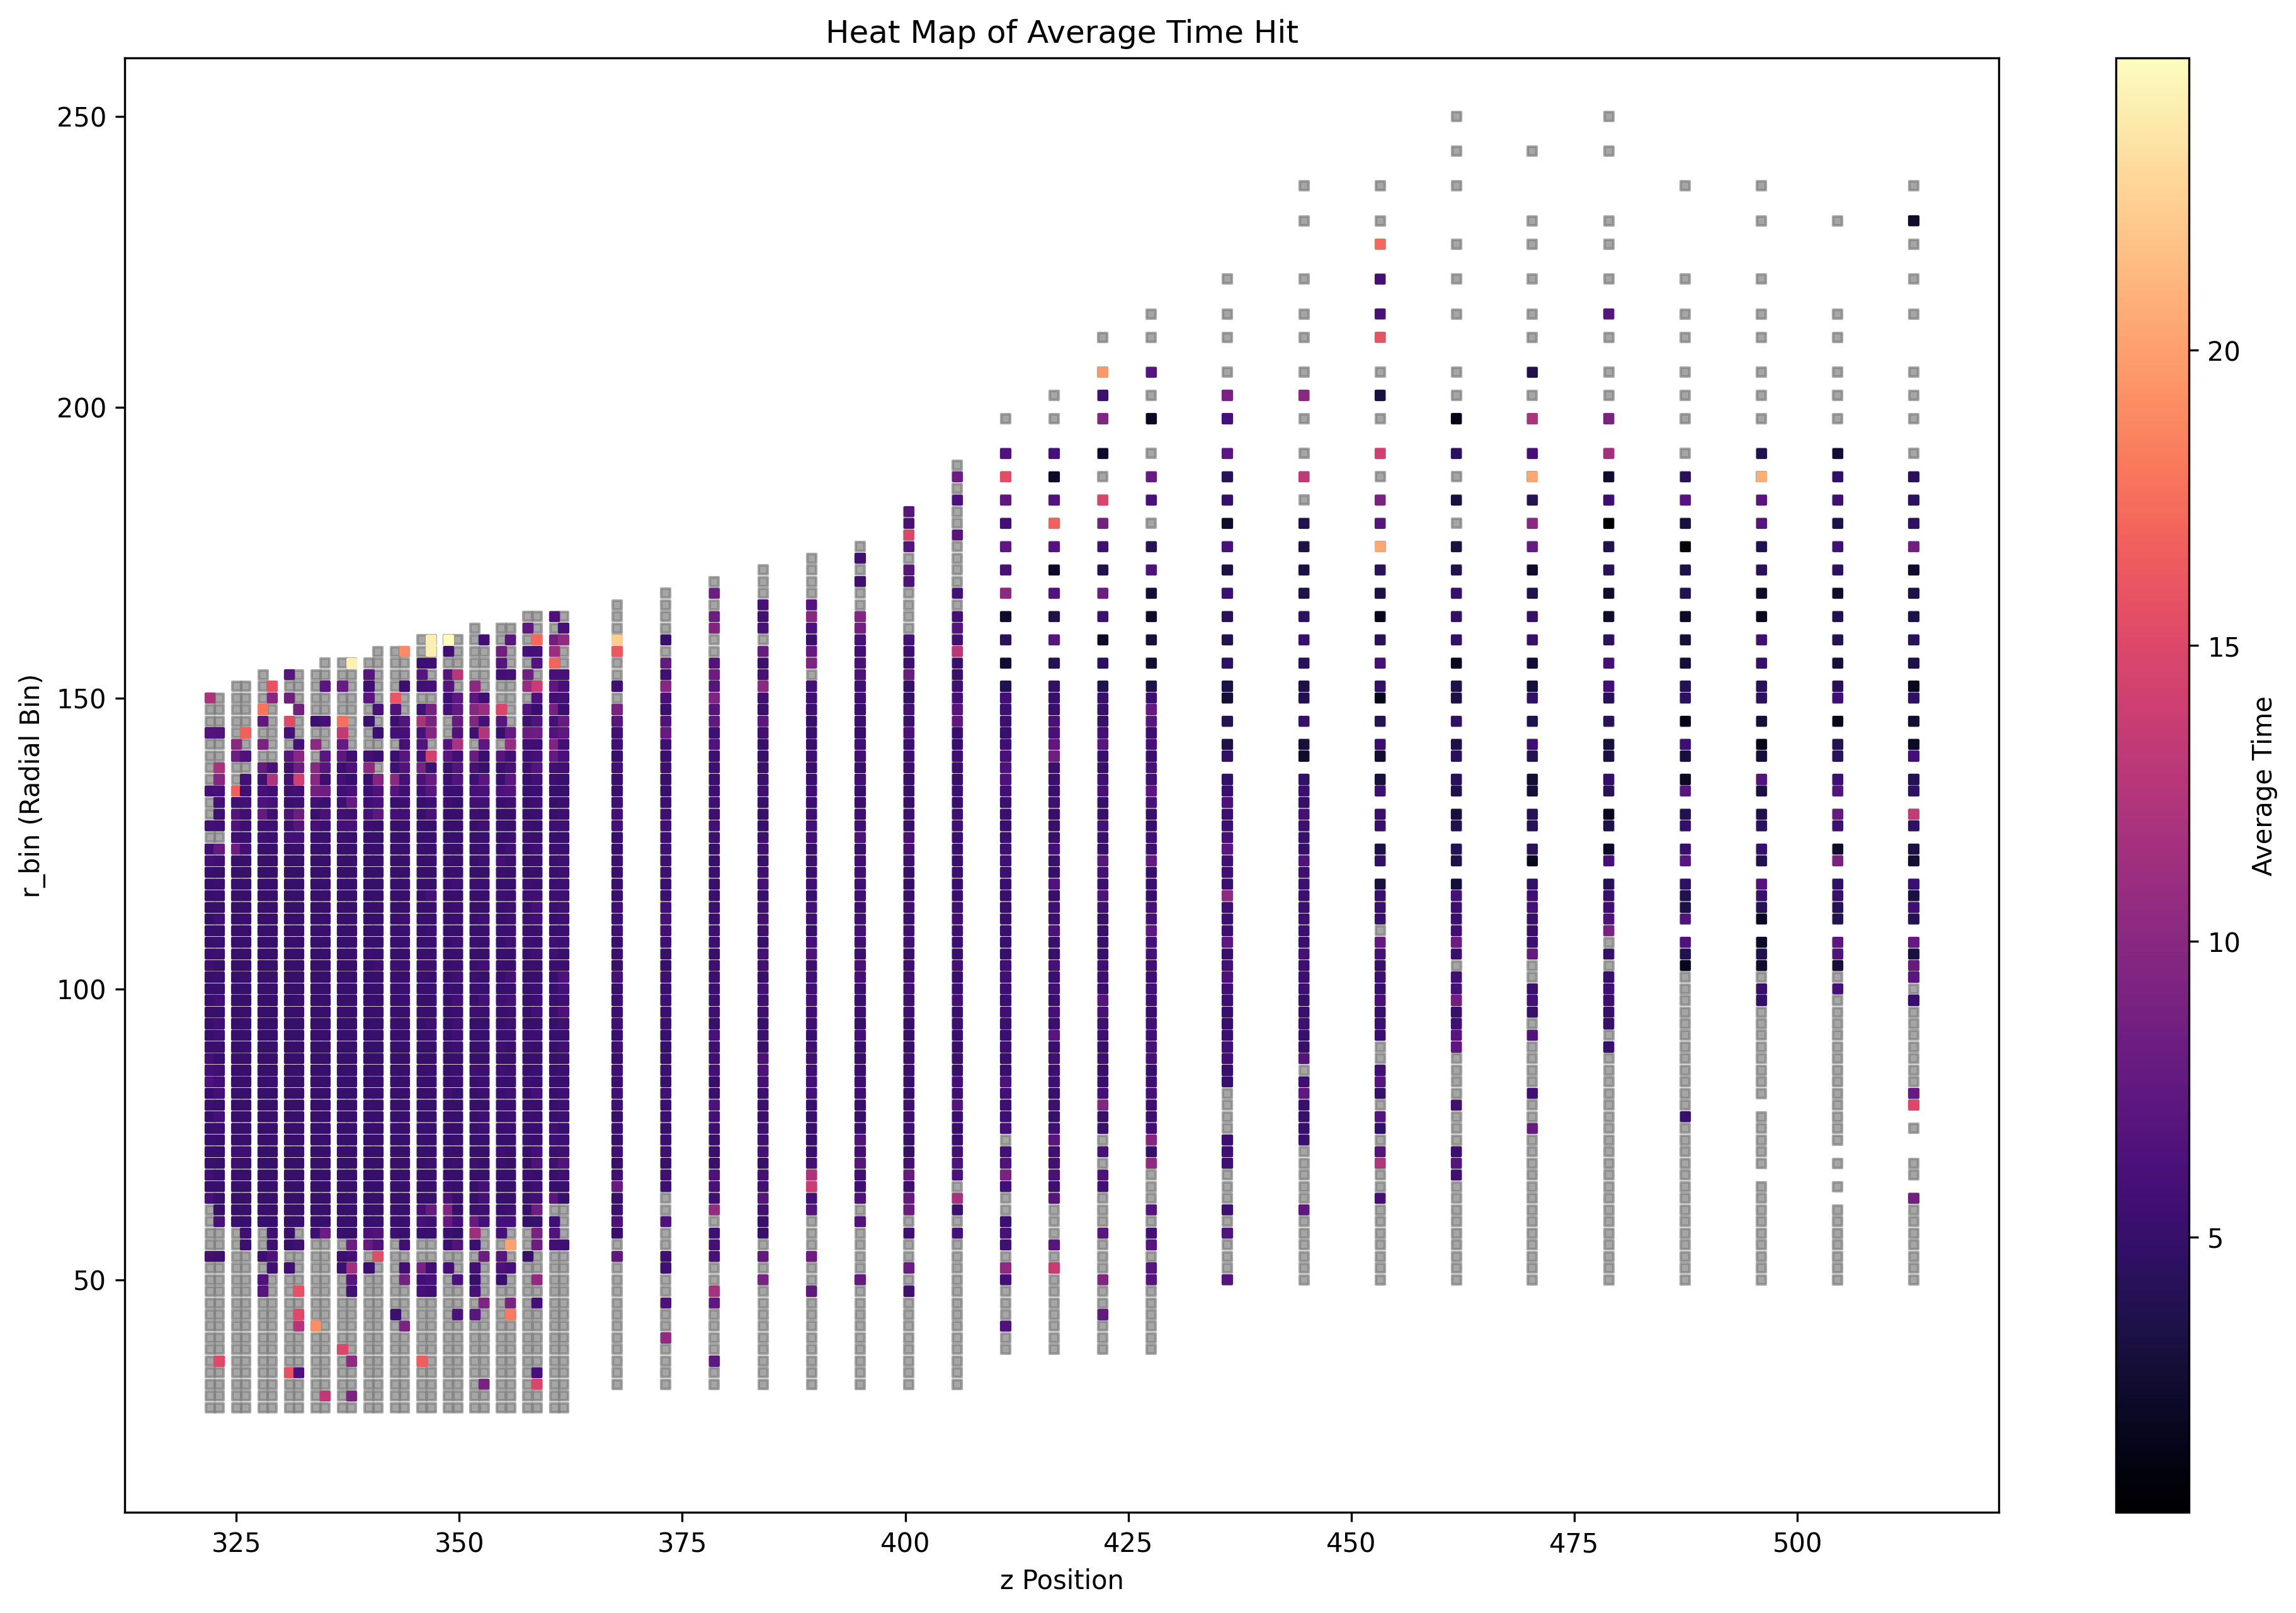

In [48]:
t_binned, _, _, _ = binned_statistic_2d(z_true_flat,r_true_flat,t_true_flat, statistic="mean",bins=(np.arange(0,51),list(range(20,261,2))))
t_binned = np.concatenate(t_binned)

with open('rzTauBinning.pkl','rb') as file:
    a = pickle.load(file)
with open('rzPionBinning.pkl','rb') as file:
    b = pickle.load(file)
with open('rzKaonBinning.pkl','rb') as file:
    c = pickle.load(file)

a = np.concatenate(a)
b = np.concatenate(b)
c = np.concatenate(c)
d = a + b + c

zbinsGrid = np.concatenate([[i]*120 for i in range(50)])
zbinsGrid = np.asarray([layer_positions[z] for z in zbinsGrid])
rbinsGrid = np.asarray(list(range(20,260,2))*50)

zbins = zbinsGrid[d != 0]
rbins = rbinsGrid[d != 0]

zbinsHits = zbinsGrid[(d != 0) & (t_binned != np.nan)]
rbinsHits = rbinsGrid[(d != 0) & (t_binned != np.nan)]
t_binned = t_binned[(d != 0) & (t_binned != np.nan)]

# 1. LOG. Scatter Plot of Noise Energy in (r, z) - No interpolation
plt.figure(figsize=(16, 10), dpi=300)
# vmin, vmax = 0, 25  # Adjust as needed
plt.scatter(zbins, rbins, s=10, marker="s", color="grey",alpha=0.7)
plt.scatter(zbinsHits, rbinsHits, c=t_binned, s=10, marker="s", cmap='magma')


cbar = plt.colorbar(label='Average Time')
# cbar.ax.set_yscale('log')
plt.ylim(10, 260)  
plt.yticks([50, 100, 150, 200, 250])  # Set specific tick marks
plt.xlabel("z Position")
plt.ylabel("r_bin (Radial Bin)")
plt.title("Heat Map of Average Time Hit")

Text(0.5, 1.0, 'Heat Map of Average Time Hit (Only < 4.5ns)')

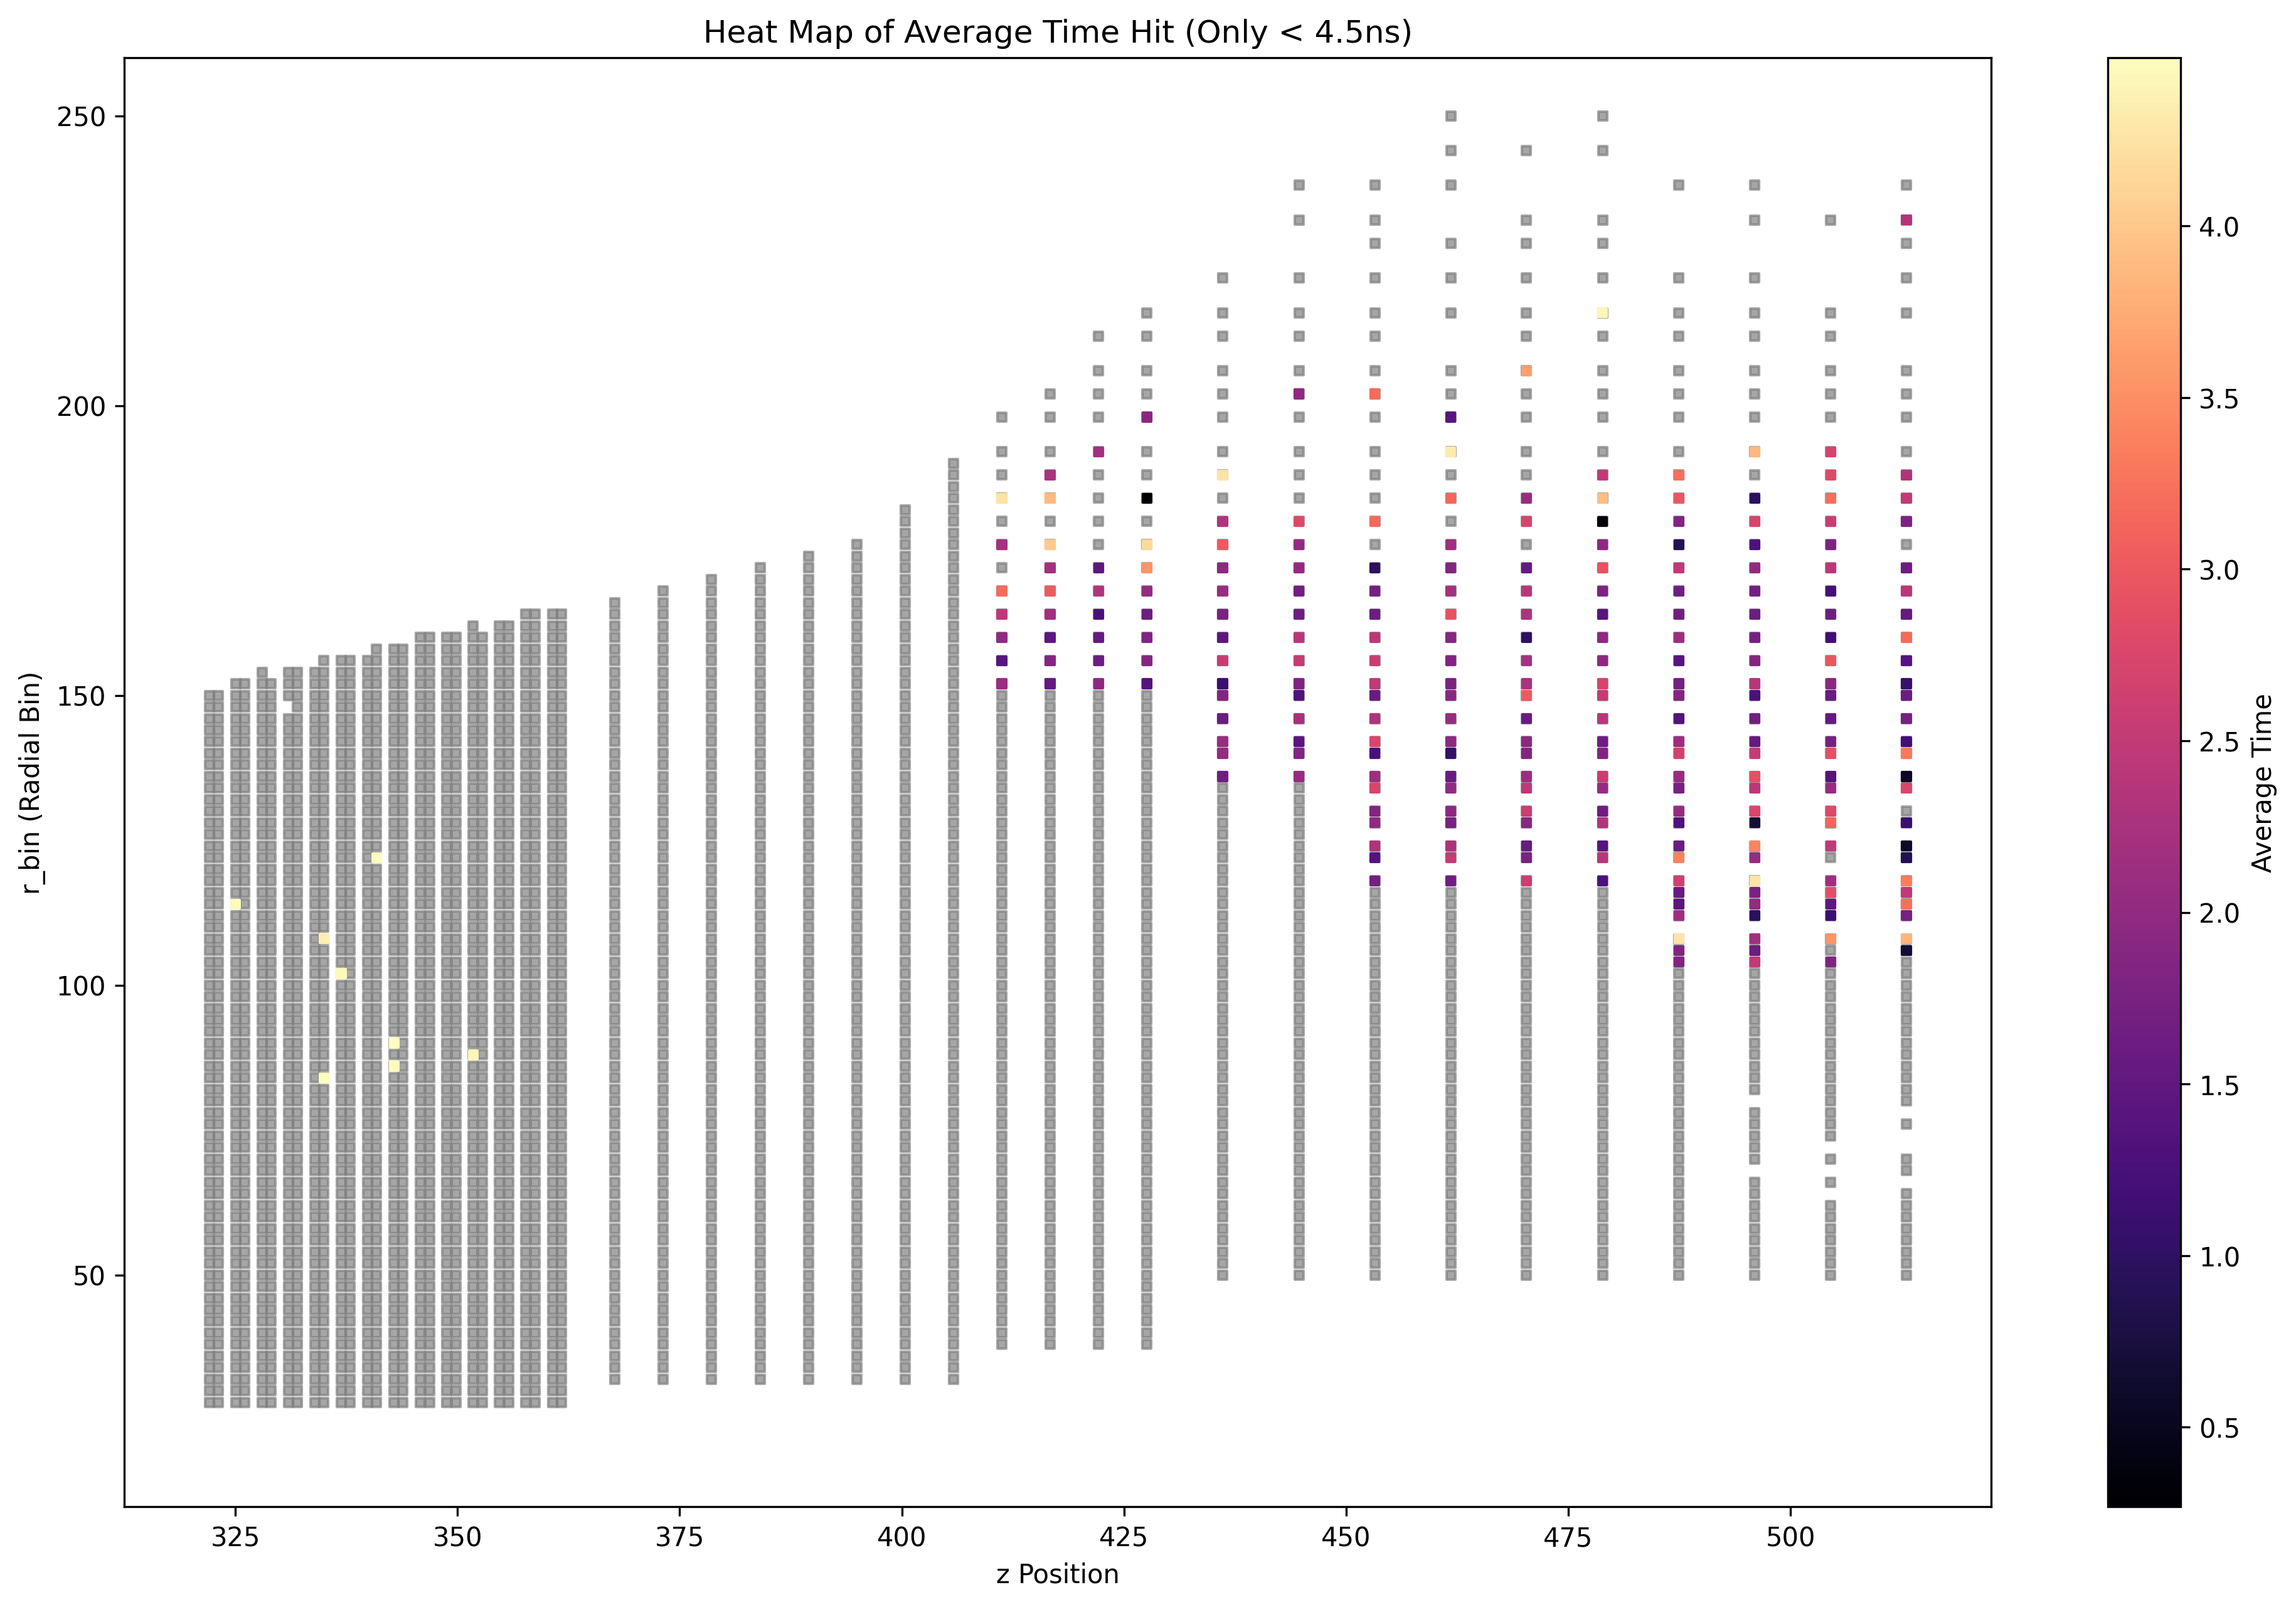

In [49]:
t_binned, _, _, _ = binned_statistic_2d(z_true_flat[t_true_flat < 4.5],r_true_flat[t_true_flat < 4.5],t_true_flat[t_true_flat < 4.5], statistic="mean",bins=(np.arange(0,51),list(range(20,261,2))))
t_binned = np.concatenate(t_binned)

with open('rzTauBinning.pkl','rb') as file:
    a = pickle.load(file)
with open('rzPionBinning.pkl','rb') as file:
    b = pickle.load(file)
with open('rzKaonBinning.pkl','rb') as file:
    c = pickle.load(file)

a = np.concatenate(a)
b = np.concatenate(b)
c = np.concatenate(c)
d = a + b + c

zbinsGrid = np.concatenate([[i]*120 for i in range(50)])
zbinsGrid = np.asarray([layer_positions[z] for z in zbinsGrid])
rbinsGrid = np.asarray(list(range(20,260,2))*50)

zbins = zbinsGrid[d != 0]
rbins = rbinsGrid[d != 0]

zbinsHits = zbinsGrid[(d != 0) & (t_binned != np.nan)]
rbinsHits = rbinsGrid[(d != 0) & (t_binned != np.nan)]
t_binned = t_binned[(d != 0) & (t_binned != np.nan)]

# 1. LOG. Scatter Plot of Noise Energy in (r, z) - No interpolation
plt.figure(figsize=(16, 10), dpi=300)
# vmin, vmax = 0, 25  # Adjust as needed
plt.scatter(zbins, rbins, s=10, marker="s", color="grey",alpha=0.7)
plt.scatter(zbinsHits, rbinsHits, c=t_binned, s=10, marker="s", cmap='magma')


cbar = plt.colorbar(label='Average Time')
# cbar.ax.set_yscale('log')
plt.ylim(10, 260)  
plt.yticks([50, 100, 150, 200, 250])  # Set specific tick marks
plt.xlabel("z Position")
plt.ylabel("r_bin (Radial Bin)")
plt.title("Heat Map of Average Time Hit (Only < 4.5ns)")